# Load dữ liệu

In [1]:
import pandas as pd

path = "./final-round.json"

# Cách 1: nếu file là 1 mảng JSON: [ {obj1}, {obj2}, ... ]
try:
    df = pd.read_json(path)
    print("Đọc JSON dạng array OK")
except ValueError:
    # Cách 2: nếu file là JSON Lines: mỗi dòng một object
    df = pd.read_json(path, lines=True)
    print("Đọc JSON dạng lines OK")

df.head()

Đọc JSON dạng array OK


,review,sentiment
0,Từ học bổng thay đổi cuộc đời đến lớp học tiến...,positive
1,Trường ĐH Tôn Đức Thắng công bố 4 nhóm nghiên ...,positive
2,Đề thi thử tốt nghiệp THPT môn Toán của thành ...,neutral
3,Sở Giáo dục TPHCM lên tiếng việc 47.000 giáo v...,neutral
4,Người mẹ trăn trở trước giờ ghi 'đơn xanh' ngu...,negative


# Kiểm tra cấu trúc tổng quan

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2444 entries, 0 to 2443
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     2444 non-null   object
 1   sentiment  2444 non-null   object
dtypes: object(2)
memory usage: 38.3+ KB


In [6]:
df.sample(5, random_state=0)


,review,sentiment
1114,"Tổng Bí thư dự gặp mặt đại biểu Bộ Quốc phòng,...",positive
1323,Bốn lý do TPHCM làm đầu tàu trong chiến lược x...,positive
2295,"Đang quay MV, nữ ca sĩ đột ngột ngất xỉu phải ...",negative
536,Lamine Yamal phá vỡ im lặng đua Quả bóng vàng ...,neutral
1190,Ông Zelensky quyết không nhượng đất lấy hòa bì...,negative


# Kiểm tra Missing values & trùng lặp

In [7]:
df.isna().sum()

review       0
sentiment    0
dtype: int64

Vậy không có dòng dữ liệu nào là Null

In [8]:
n_before = len(df)
n_dup_full = df.duplicated().sum()
print("Số dòng trùng hoàn toàn:", n_dup_full)

df = df.drop_duplicates()
print("Đã drop", n_before - len(df), "dòng trùng hoàn toàn")

Số dòng trùng hoàn toàn: 0
Đã drop 0 dòng trùng hoàn toàn


In [9]:
# Số review duy nhất
n_unique_review = df["review"].nunique()
print("Tổng review:", len(df))
print("Review duy nhất:", n_unique_review)

# Những review xuất hiện với >1 nhãn
dup_review = (df.groupby("review")["sentiment"]
                .nunique()
                .reset_index(name="n_labels"))
dup_conflict = dup_review[dup_review["n_labels"] > 1]

print("Số review có >1 nhãn khác nhau:", len(dup_conflict))
dup_conflict.head()

Tổng review: 2444
Review duy nhất: 2444
Số review có >1 nhãn khác nhau: 0


,review,n_labels


# Phân bố nhãn (class distribution)

In [10]:
label_counts = df["sentiment"].value_counts()
label_pct = df["sentiment"].value_counts(normalize=True) * 100

print(label_counts)
print(label_pct.round(2))

sentiment
neutral     964
negative    756
positive    724
Name: count, dtype: int64
sentiment
neutral     39.44
negative    30.93
positive    29.62
Name: proportion, dtype: float64


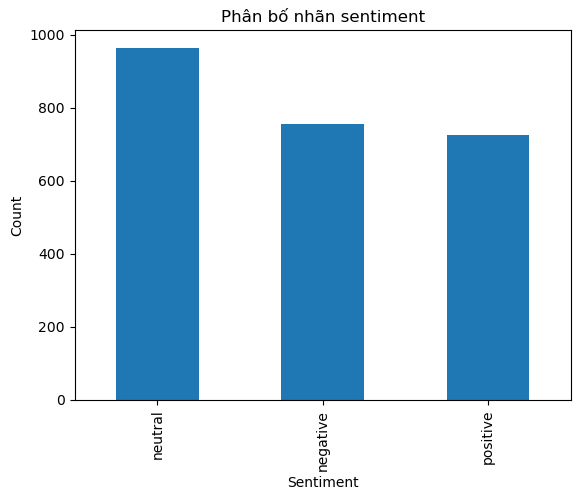

In [11]:
import matplotlib.pyplot as plt

label_counts.plot(kind="bar")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Phân bố nhãn sentiment")
plt.show()

# Độ dài review (char/word)

In [12]:
df["len_char"] = df["review"].str.len()
df["len_word"] = df["review"].str.split().str.len()

In [13]:
df[["len_char", "len_word"]].describe()


,len_char,len_word
count,2444.000000,2444.000000
mean,238.051964,52.999182
std,42.524493,9.775248
min,116.000000,24.000000
25%,207.000000,46.000000
50%,235.000000,52.000000
75%,269.000000,60.000000
max,345.000000,80.000000


# EDA từ vựng (lexical)

## Tiền xử lý đơn giản cho EDA

In [15]:
import re

def clean_review(text):
    # Nếu không phải string thì trả về chuỗi rỗng
    if not isinstance(text, str):
        return ""
    
    # 1) Viết thường hết
    text = text.lower()
    
    # 2) Bỏ tất cả số
    text = re.sub(r"\d+", " ", text)
    
    # 3) Bỏ các ký hiệu, dấu câu (chỉ giữ lại chữ + khoảng trắng)
    # [^\w\s] = mọi thứ KHÔNG phải chữ/các ký tự "word" hoặc khoảng trắng
    # flags=re.UNICODE để hỗ trợ chữ có dấu tiếng Việt
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    
    # 3b) Bỏ riêng dấu gạch dưới "_" nếu còn
    text = text.replace("_", " ")
    
    # 4) Thu gọn khoảng trắng thừa
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


In [16]:
df["review_clean"] = df["review"].apply(clean_review)

In ra một vài mẫu kiểm tra sau xử lý đơn giản

In [17]:
df[["review", "review_clean", "sentiment"]].sample(10, random_state=0)


,review,review_clean,sentiment
1114,"Tổng Bí thư dự gặp mặt đại biểu Bộ Quốc phòng,...",tổng bí thư dự gặp mặt đại biểu bộ quốc phòng ...,positive
1323,Bốn lý do TPHCM làm đầu tàu trong chiến lược x...,bốn lý do tphcm làm đầu tàu trong chiến lược x...,positive
2295,"Đang quay MV, nữ ca sĩ đột ngột ngất xỉu phải ...",đang quay mv nữ ca sĩ đột ngột ngất xỉu phải n...,negative
536,Lamine Yamal phá vỡ im lặng đua Quả bóng vàng ...,lamine yamal phá vỡ im lặng đua quả bóng vàng ...,neutral
1190,Ông Zelensky quyết không nhượng đất lấy hòa bì...,ông zelensky quyết không nhượng đất lấy hòa bì...,negative
986,Giá vàng hôm nay 19/7/2025: Vàng miếng SJC chố...,giá vàng hôm nay vàng miếng sjc chốt tuần tăng...,neutral
2426,"Nga ra tối hậu thư, ông Trump muốn ông Putin t...",nga ra tối hậu thư ông trump muốn ông putin th...,negative
1284,Bộ trưởng Công an: Chính các bạn trẻ phải bảo ...,bộ trưởng công an chính các bạn trẻ phải bảo v...,positive
2137,Chi tiết bộ máy Quốc hội và nhân sự Ủy ban Thư...,chi tiết bộ máy quốc hội và nhân sự ủy ban thư...,neutral
2015,4 huyền thoại Man United khiến fan Việt vỡ oà ...,huyền thoại man united khiến fan việt vỡ oà cả...,positive


## Đếm từ phổ biến toàn corpus

In [18]:
from collections import Counter

all_words = " ".join(df["review_clean"]).split()
word_counts = Counter(all_words)
word_counts.most_common(50)

[('và', 1189),
 ('của', 1083),
 ('công', 975),
 ('trong', 914),
 ('người', 893),
 ('có', 810),
 ('ở', 753),
 ('với', 708),
 ('cho', 651),
 ('không', 637),
 ('đã', 624),
 ('các', 623),
 ('nam', 619),
 ('một', 597),
 ('được', 596),
 ('đồng', 593),
 ('bị', 571),
 ('quốc', 568),
 ('tại', 554),
 ('khi', 524),
 ('về', 523),
 ('bộ', 523),
 ('là', 497),
 ('việt', 494),
 ('xe', 487),
 ('năm', 486),
 ('để', 443),
 ('chính', 425),
 ('nhà', 422),
 ('vào', 420),
 ('nhân', 418),
 ('sau', 416),
 ('từ', 408),
 ('hàng', 407),
 ('đầu', 397),
 ('trung', 395),
 ('động', 389),
 ('học', 385),
 ('trên', 381),
 ('nước', 379),
 ('định', 377),
 ('nội', 377),
 ('thành', 374),
 ('ra', 371),
 ('cấp', 367),
 ('nhiều', 366),
 ('hà', 365),
 ('an', 352),
 ('làm', 345),
 ('hành', 343)]

## Đếm từ theo từng nhãn

In [20]:
def top_words_for_label(label, n=30):
    subset = df[df["sentiment"] == label]
    words = " ".join(subset["review_clean"]).split()
    return Counter(words).most_common(n)

top_pos = top_words_for_label("positive", 30)
top_neu = top_words_for_label("neutral", 30)
top_neg = top_words_for_label("negative", 30)

print("Số từ theo nhãn positive", top_pos)
print("Số từ theo nhãn neutral", top_neu)
print("Số từ theo nhãn negative", top_neg)

Số từ theo nhãn positive [('và', 436), ('của', 349), ('công', 294), ('nam', 275), ('trong', 270), ('việt', 268), ('với', 240), ('cho', 225), ('người', 224), ('được', 217), ('có', 214), ('là', 213), ('quốc', 199), ('tại', 190), ('các', 184), ('một', 175), ('năm', 174), ('đồng', 165), ('ở', 161), ('học', 160), ('thành', 159), ('đầu', 159), ('không', 158), ('đã', 152), ('mới', 147), ('về', 146), ('động', 145), ('để', 137), ('nhà', 133), ('nhân', 128)]
Số từ theo nhãn neutral [('và', 492), ('của', 403), ('có', 402), ('công', 373), ('trong', 361), ('bộ', 330), ('với', 307), ('các', 292), ('cho', 263), ('về', 257), ('không', 256), ('năm', 247), ('được', 246), ('đồng', 244), ('chính', 243), ('giá', 235), ('người', 233), ('ở', 227), ('quốc', 226), ('nam', 203), ('tại', 201), ('định', 200), ('là', 198), ('khi', 191), ('việt', 187), ('nay', 184), ('cấp', 183), ('một', 181), ('đã', 178), ('trung', 172)]
Số từ theo nhãn negative [('người', 436), ('bị', 417), ('ở', 365), ('của', 331), ('công', 308)

## Trực quan hoá cho dễ nhìn

In [21]:
import pandas as pd
from collections import Counter

# df đã load và có cột review_clean
# df["review_clean"] = df["review"].apply(clean_review)  # đã làm ở bước trước

# Tách tất cả từ trong toàn corpus
all_words = " ".join(df["review_clean"]).split()
word_counts = Counter(all_words)

# Lấy top 30 từ phổ biến nhất
top_n = 30
top_words_all = word_counts.most_common(top_n)
top_words_all[:10]

[('và', 1189),
 ('của', 1083),
 ('công', 975),
 ('trong', 914),
 ('người', 893),
 ('có', 810),
 ('ở', 753),
 ('với', 708),
 ('cho', 651),
 ('không', 637)]

In [22]:
def top_words_for_label(label, n=30):
    subset = df[df["sentiment"] == label]
    words = " ".join(subset["review_clean"]).split()
    return Counter(words).most_common(n)

labels = df["sentiment"].unique().tolist()  # ví dụ: ["positive", "neutral", "negative"]

top_words_by_label = {
    label: top_words_for_label(label, top_n)
    for label in labels
}


Hàm vẽ bar chart đẹp

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def plot_top_words(top_words, title, color=None, figsize=(10, 6)):
    """
    top_words: list of (word, count)
    title: tiêu đề
    color: màu cho cột (chuỗi hoặc list), nếu None sẽ dùng màu mặc định
    """
    words = [w for w, c in top_words]
    counts = [c for w, c in top_words]

    # Đảo ngược để vẽ barh từ dưới lên trên (top ở trên cùng)
    words = words[::-1]
    counts = counts[::-1]

    plt.figure(figsize=figsize)

    y_pos = np.arange(len(words))

    if color is None:
        plt.barh(y_pos, counts)
    else:
        plt.barh(y_pos, counts, color=color)

    plt.yticks(y_pos, words, fontsize=10)
    plt.xlabel("Tần suất", fontsize=12)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


Trực quan hóa top từ phổ biến toàn bộ dữ liệu

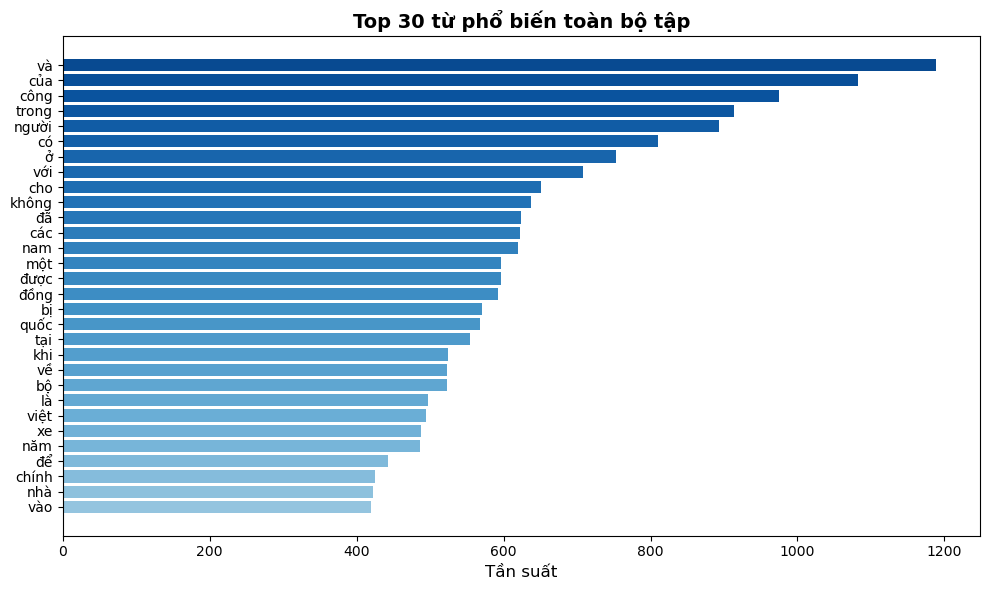

In [25]:
# Tạo màu gradient cho top N từ
from matplotlib import cm

colors_all = cm.Blues(np.linspace(0.4, 0.9, top_n))  # xanh dương nhạt → đậm

plot_top_words(
    top_words_all,
    title=f"Top {top_n} từ phổ biến toàn bộ tập",
    color=colors_all
)


Trực quan hóa top từ theo từng nhãn sentiment

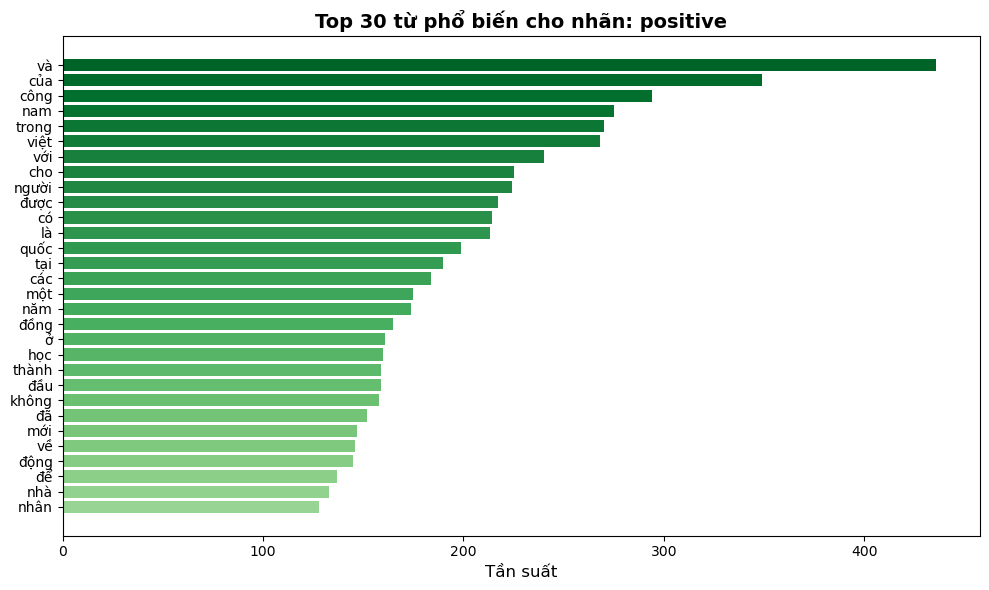

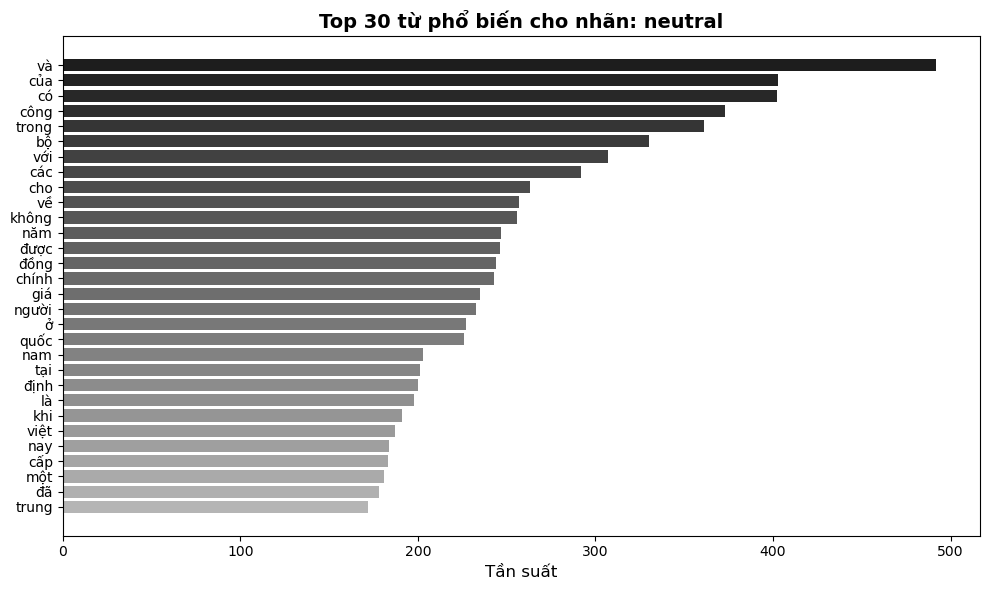

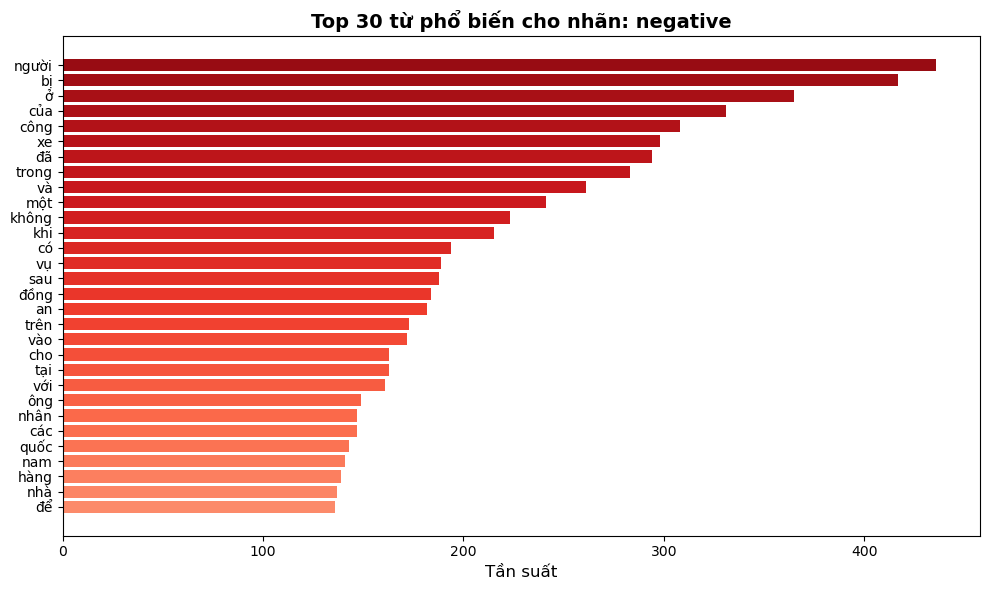

In [26]:
from matplotlib import cm

# Map nhãn → colormap
label_cmaps = {
    "positive": cm.Greens,
    "neutral": cm.Greys,
    "negative": cm.Reds
}

for label in labels:
    top_words = top_words_by_label[label]
    cmap = label_cmaps.get(label, cm.Blues)  # fallback nếu nhãn lạ
    colors = cmap(np.linspace(0.4, 0.9, len(top_words)))  # gradient

    plot_top_words(
        top_words,
        title=f"Top {len(top_words)} từ phổ biến cho nhãn: {label}",
        color=colors
    )


# WORDCLOUD

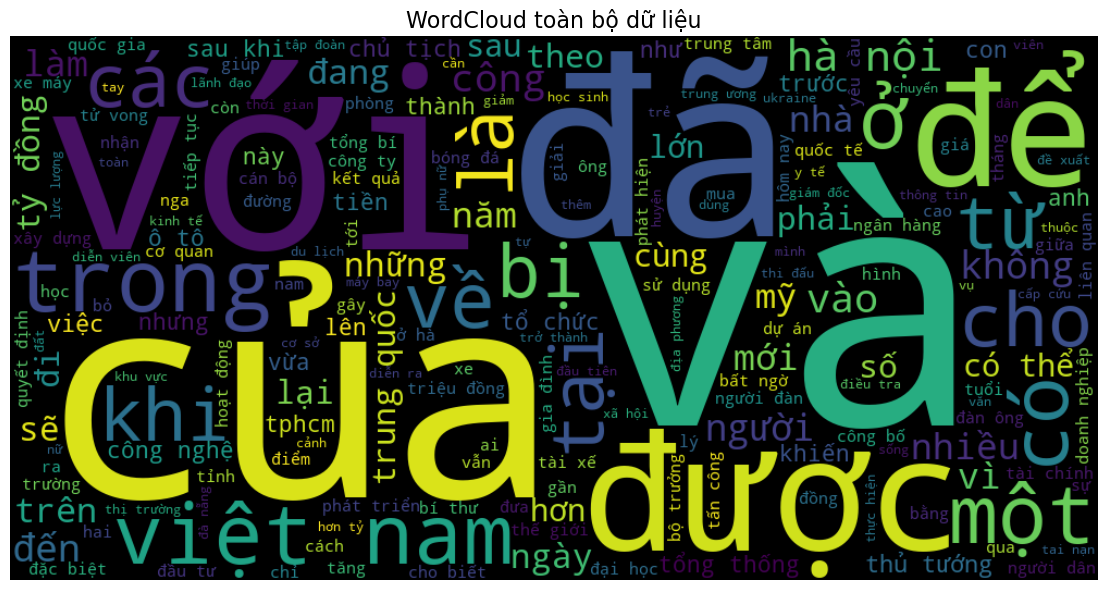

In [28]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ghép tất cả review_clean thành một chuỗi dài
text_all = " ".join(df["review_clean"].tolist())

# Tạo wordcloud (dùng màu mặc định)
wc_all = WordCloud(
    width=1000,
    height=500
).generate(text_all)

plt.figure(figsize=(12, 6))
plt.imshow(wc_all, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud toàn bộ dữ liệu", fontsize=16)
plt.tight_layout()
plt.show()

# Tách tập train và tập test, lưu xuống file

## Load và lưu

In [1]:
import pandas as pd

path = "./final-round.json"

# Nếu file là mảng JSON [ {...}, {...}, ... ]
try:
    df = pd.read_json(path)
    print("Đọc JSON dạng array OK")
except ValueError:
    # Nếu là JSON lines (mỗi dòng 1 object)
    df = pd.read_json(path, lines=True)
    print("Đọc JSON dạng lines OK")

df.head()


Đọc JSON dạng array OK


,review,sentiment
0,Từ học bổng thay đổi cuộc đời đến lớp học tiến...,positive
1,Trường ĐH Tôn Đức Thắng công bố 4 nhóm nghiên ...,positive
2,Đề thi thử tốt nghiệp THPT môn Toán của thành ...,neutral
3,Sở Giáo dục TPHCM lên tiếng việc 47.000 giáo v...,neutral
4,Người mẹ trăn trở trước giờ ghi 'đơn xanh' ngu...,negative


In [2]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment"]  # để giữ tỉ lệ nhãn
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))


Train size: 1955
Test size: 489


In [3]:
train_df.to_json(
    "./train-raw.json",
    orient="records",
    force_ascii=False,
    indent=2
)

test_df.to_json(
    "./test-raw.json",
    orient="records",
    force_ascii=False,
    indent=2
)


## Preprocessing Data

In [4]:
import re

def clean_review_basic(text):
    # Nếu không phải string → trả chuỗi rỗng
    if not isinstance(text, str):
        return ""
    
    # 1) viết thường
    text = text.lower()
    
    # 2) bỏ số
    text = re.sub(r"\d+", " ", text)
    
    # 3) bỏ các ký hiệu, dấu câu (giữ chữ + khoảng trắng)
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    
    # bỏ riêng dấu gạch dưới nếu còn
    text = text.replace("_", " ")
    
    # 4) thu gọn khoảng trắng
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


In [5]:
import unicodedata

def remove_vietnamese_diacritics(text):
    """
    Bỏ dấu tiếng Việt, giữ lại chữ cái không dấu.
    """
    if not isinstance(text, str):
        return ""
    
    # Chuẩn hóa sang dạng tách dấu
    text = unicodedata.normalize('NFD', text)
    # Loại bỏ các ký tự thuộc nhóm dấu (Mn = nonspacing mark)
    text = "".join(ch for ch in text if unicodedata.category(ch) != 'Mn')
    # Chuẩn hóa lại
    text = unicodedata.normalize('NFC', text)
    return text


In [6]:
# Đọc file stopword
stopword_path = "./vietnamese-stopwords.txt"

with open(stopword_path, "r", encoding="utf-8") as f:
    stopwords_raw = [line.strip() for line in f if line.strip()]

# Chuẩn hóa stopword: viết thường + bỏ dấu
stopwords = set(
    remove_vietnamese_diacritics(sw.lower())
    for sw in stopwords_raw
)
print("Số lượng stopword:", len(stopwords))

Số lượng stopword: 1844


In [7]:
def preprocess_review(text, stopwords):
    # Bước 1: clean cơ bản (EDA)
    text = clean_review_basic(text)
    
    # Bước 2: bỏ dấu tiếng Việt
    text = remove_vietnamese_diacritics(text)
    
    # Bước 3: bỏ stopword
    tokens = text.split()
    tokens = [tok for tok in tokens if tok not in stopwords]
    
    # Ghép lại
    return " ".join(tokens)


In [8]:
# Tạo cột mới: review_processed
train_df["review_processed"] = train_df["review"].apply(
    lambda x: preprocess_review(x, stopwords)
)

test_df["review_processed"] = test_df["review"].apply(
    lambda x: preprocess_review(x, stopwords)
)

In [9]:
train_df = train_df[train_df["review_processed"].str.strip().astype(bool)]
test_df  = test_df[test_df["review_processed"].str.strip().astype(bool)]

print("Train size after dropping empty:", len(train_df))
print("Test size after dropping empty:", len(test_df))


Train size after dropping empty: 1955
Test size after dropping empty: 489


In [10]:
# Tạo bản chỉ còn cột cần dùng
train_proc = train_df[["review_processed", "sentiment"]].rename(
    columns={"review_processed": "review"}
)

test_proc = test_df[["review_processed", "sentiment"]].rename(
    columns={"review_processed": "review"}
)

# Lưu ra JSON (chữ tiếng Việt không bị mã hóa)
train_proc.to_json(
    "./train-preprocessed.json",
    orient="records",
    force_ascii=False,
    indent=2
)

test_proc.to_json(
    "./test-preprocessed.json",
    orient="records",
    force_ascii=False,
    indent=2
)


## EDA

In [11]:
import pandas as pd

train_path = "./train-preprocessed.json"
test_path  = "./test-preprocessed.json"

train = pd.read_json(train_path)
test  = pd.read_json(test_path)

print("Train size:", len(train))
print("Test size:", len(test))
train.head()


Train size: 1955
Test size: 489


,review,sentiment
0,khu giau ha menh mong đuong song mua trua đuon...,negative
1,mau xe hybrid nissan kicks trieu viet pin chay...,negative
2,truong my yeu đam nga ukraine đot pha truong m...,neutral
3,đac gai hien than cuu me xet nghiem than phu h...,positive
4,chau ga đan vac truy am uc ngo đap chet ga uon...,negative


### Phân bố nhãn

In [12]:
train_counts = train["sentiment"].value_counts().sort_index()
test_counts  = test["sentiment"].value_counts().sort_index()

print("Train label counts:")
print(train_counts)
print("\nTest label counts:")
print(test_counts)


Train label counts:
sentiment
negative    605
neutral     771
positive    579
Name: count, dtype: int64

Test label counts:
sentiment
negative    151
neutral     193
positive    145
Name: count, dtype: int64


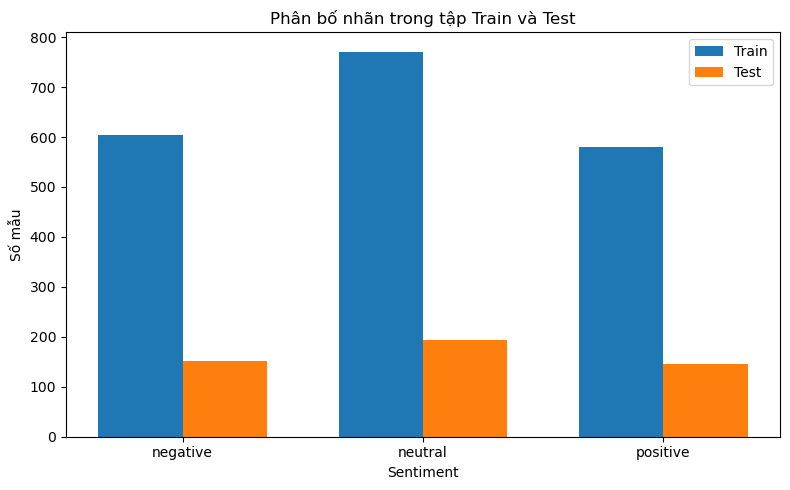

In [13]:
import matplotlib.pyplot as plt
import numpy as np

labels = sorted(train["sentiment"].unique().tolist())  # đảm bảo cùng thứ tự
train_vals = train_counts[labels].values
test_vals  = test_counts[labels].values

x = np.arange(len(labels))  # vị trí nhãn trên trục x
width = 0.35                # độ rộng mỗi cột

plt.figure(figsize=(8, 5))

# Cột train
plt.bar(x - width/2, train_vals, width=width, label="Train")
# Cột test
plt.bar(x + width/2, test_vals, width=width, label="Test")

plt.xticks(x, labels)
plt.xlabel("Sentiment")
plt.ylabel("Số mẫu")
plt.title("Phân bố nhãn trong tập Train và Test")
plt.legend()
plt.tight_layout()
plt.show()


### Từ phổ biến trong mỗi tập (train/test)

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

def plot_top_words_from_series(text_series, title, top_n=20, cmap=None, figsize=(10, 6)):
    """
    text_series: một Series chứa các câu (review)
    title: tiêu đề chart
    top_n: số từ phổ biến muốn hiển thị
    cmap: colormap của matplotlib (vd: cm.Blues, cm.Reds,...)
    """
    # Ghép toàn bộ review lại và tách token
    tokens = " ".join(text_series.tolist()).split()
    counts = Counter(tokens)
    top_words = counts.most_common(top_n)
    
    if not top_words:
        print(f"{title}: không đủ dữ liệu để vẽ.")
        return
    
    words = [w for w, c in top_words][::-1]   # đảo ngược để top nằm trên cùng
    freqs = [c for w, c in top_words][::-1]
    
    y_pos = np.arange(len(words))
    
    # Tạo màu
    if cmap is not None:
        from matplotlib import cm
        colors = cmap(np.linspace(0.4, 0.9, len(words)))
    else:
        colors = None
    
    plt.figure(figsize=figsize)
    plt.barh(y_pos, freqs, color=colors)
    plt.yticks(y_pos, words, fontsize=10)
    plt.xlabel("Tần suất")
    plt.title(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


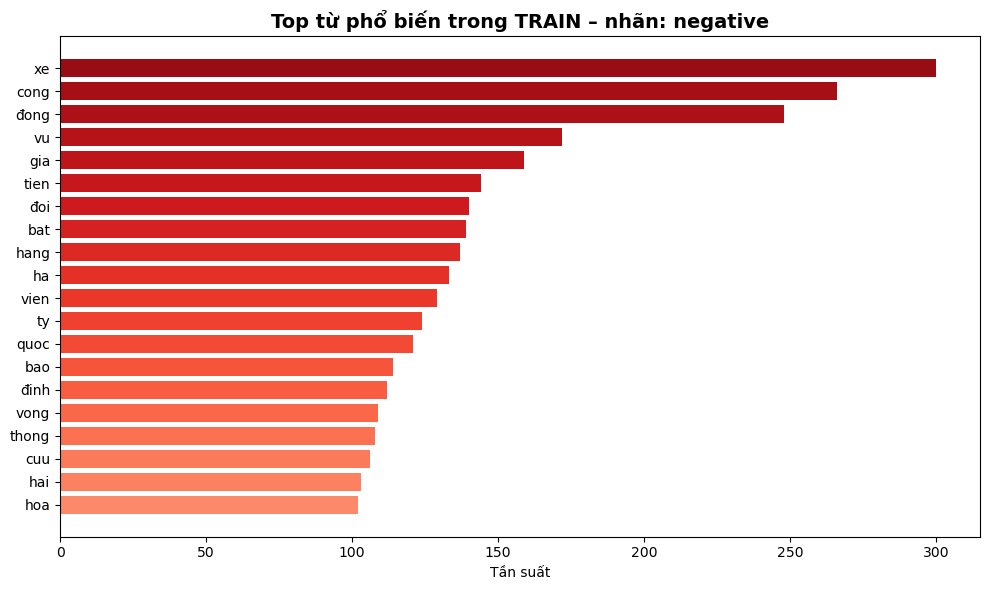

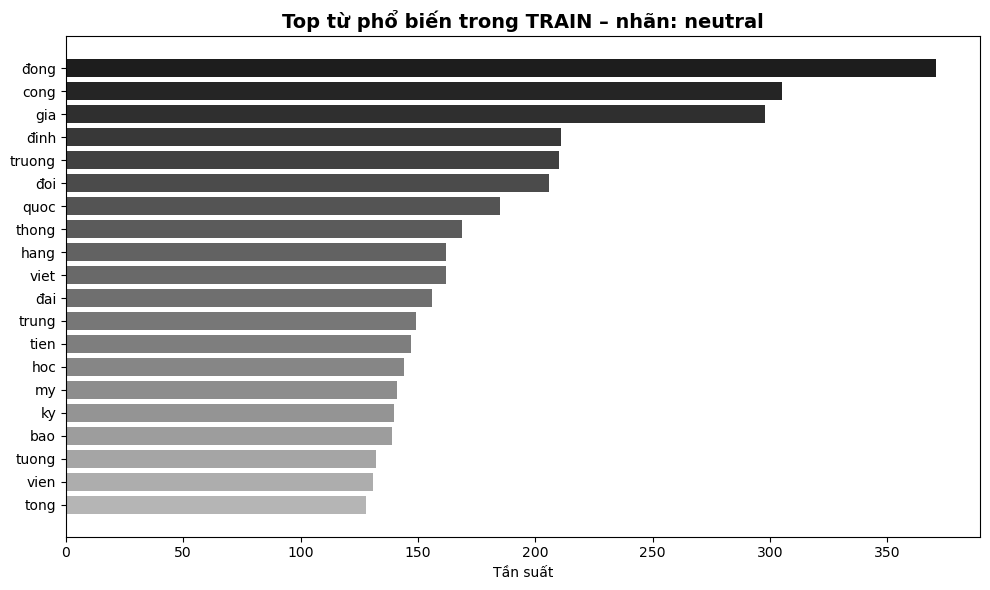

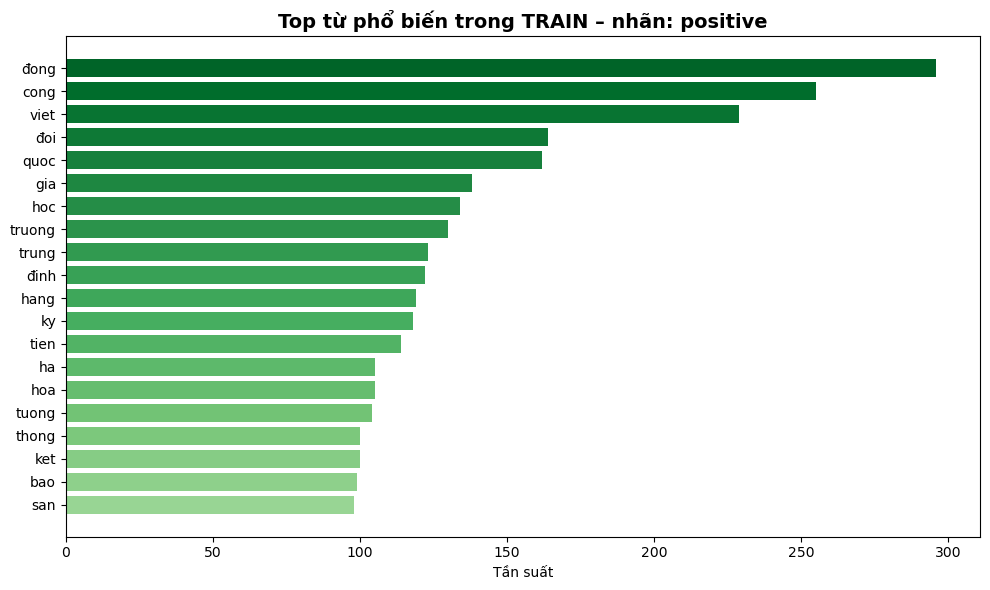

In [22]:
from matplotlib import cm

labels_train = sorted(train["sentiment"].unique().tolist())
cmap_map = {
    "positive": cm.Greens,
    "neutral": cm.Greys,
    "negative": cm.Reds
}

for label in labels_train:
    subset = train[train["sentiment"] == label]["review"]
    cmap = cmap_map.get(label, cm.Blues)
    
    plot_top_words_from_series(
        subset,
        title=f"Top từ phổ biến trong TRAIN – nhãn: {label}",
        top_n=20,
        cmap=cmap
    )


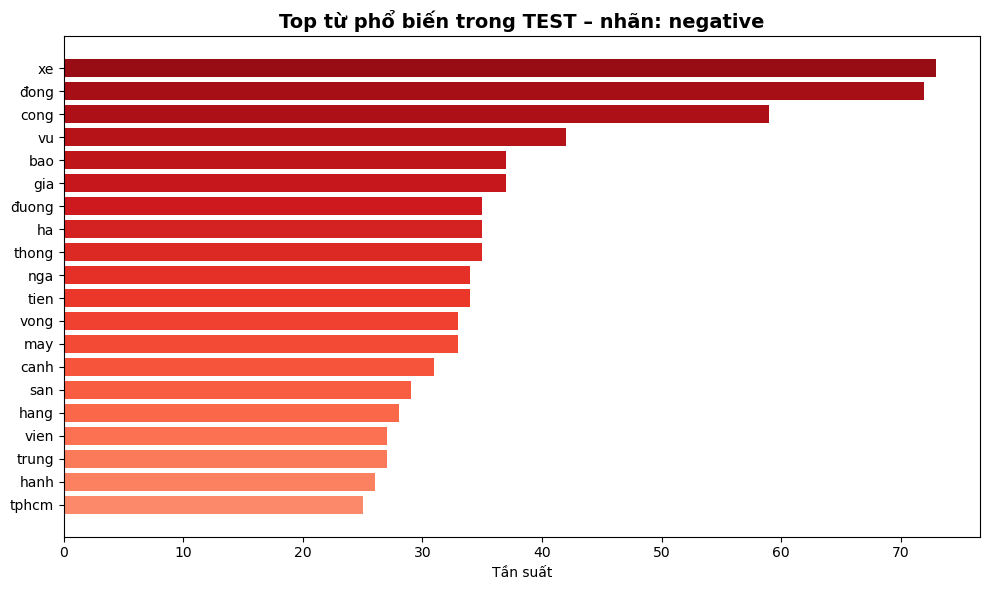

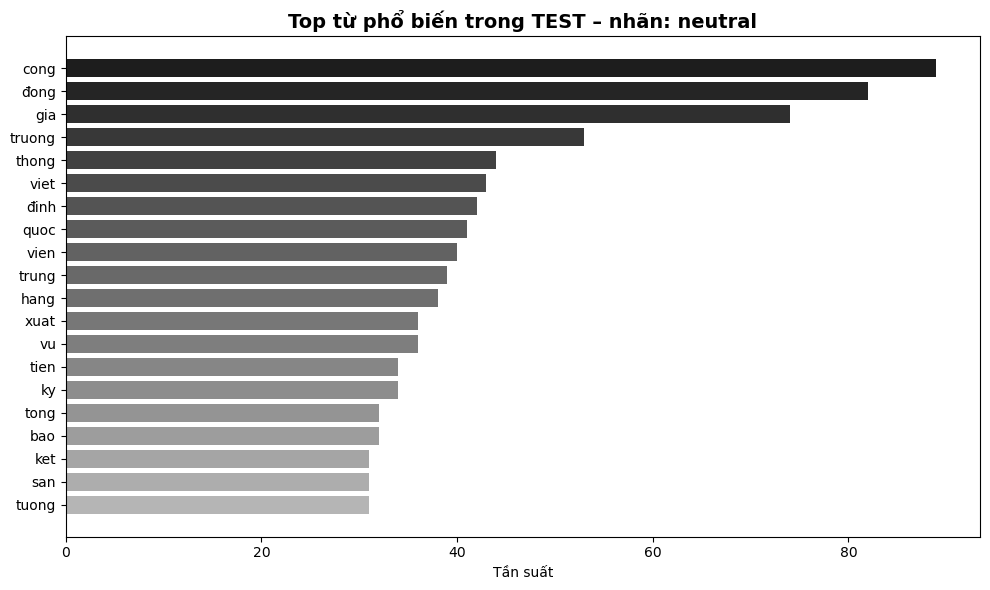

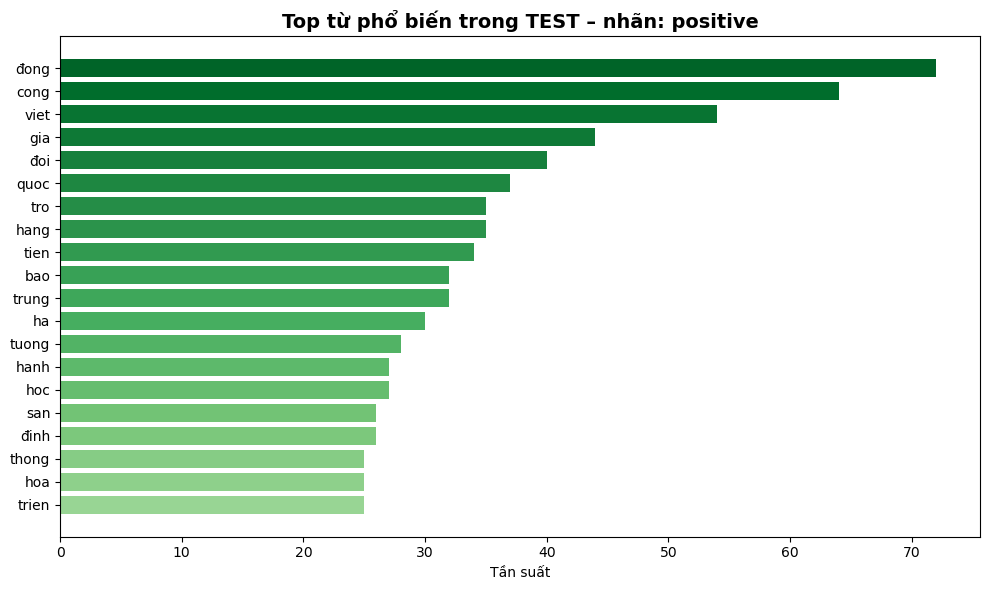

In [23]:
labels_test = sorted(test["sentiment"].unique().tolist())

for label in labels_test:
    subset = test[test["sentiment"] == label]["review"]
    cmap = cmap_map.get(label, cm.Blues)
    
    plot_top_words_from_series(
        subset,
        title=f"Top từ phổ biến trong TEST – nhãn: {label}",
        top_n=20,
        cmap=cmap
    )
